In [1]:
import anti_symmetric_dp
import pandas as pd
import numpy as np

10
[(0.0, 18.01056), (299.15536, 18.01056), (299.15536, 400.28704), (414.18229999999994, 400.28704), (414.18229999999994, 499.35544999999996), (527.26636, 499.35544999999996), (598.30347, 499.35544999999996), (598.30347, 628.39804), (598.30347, 756.45662), (792.38384, 756.45662), 'Sink']


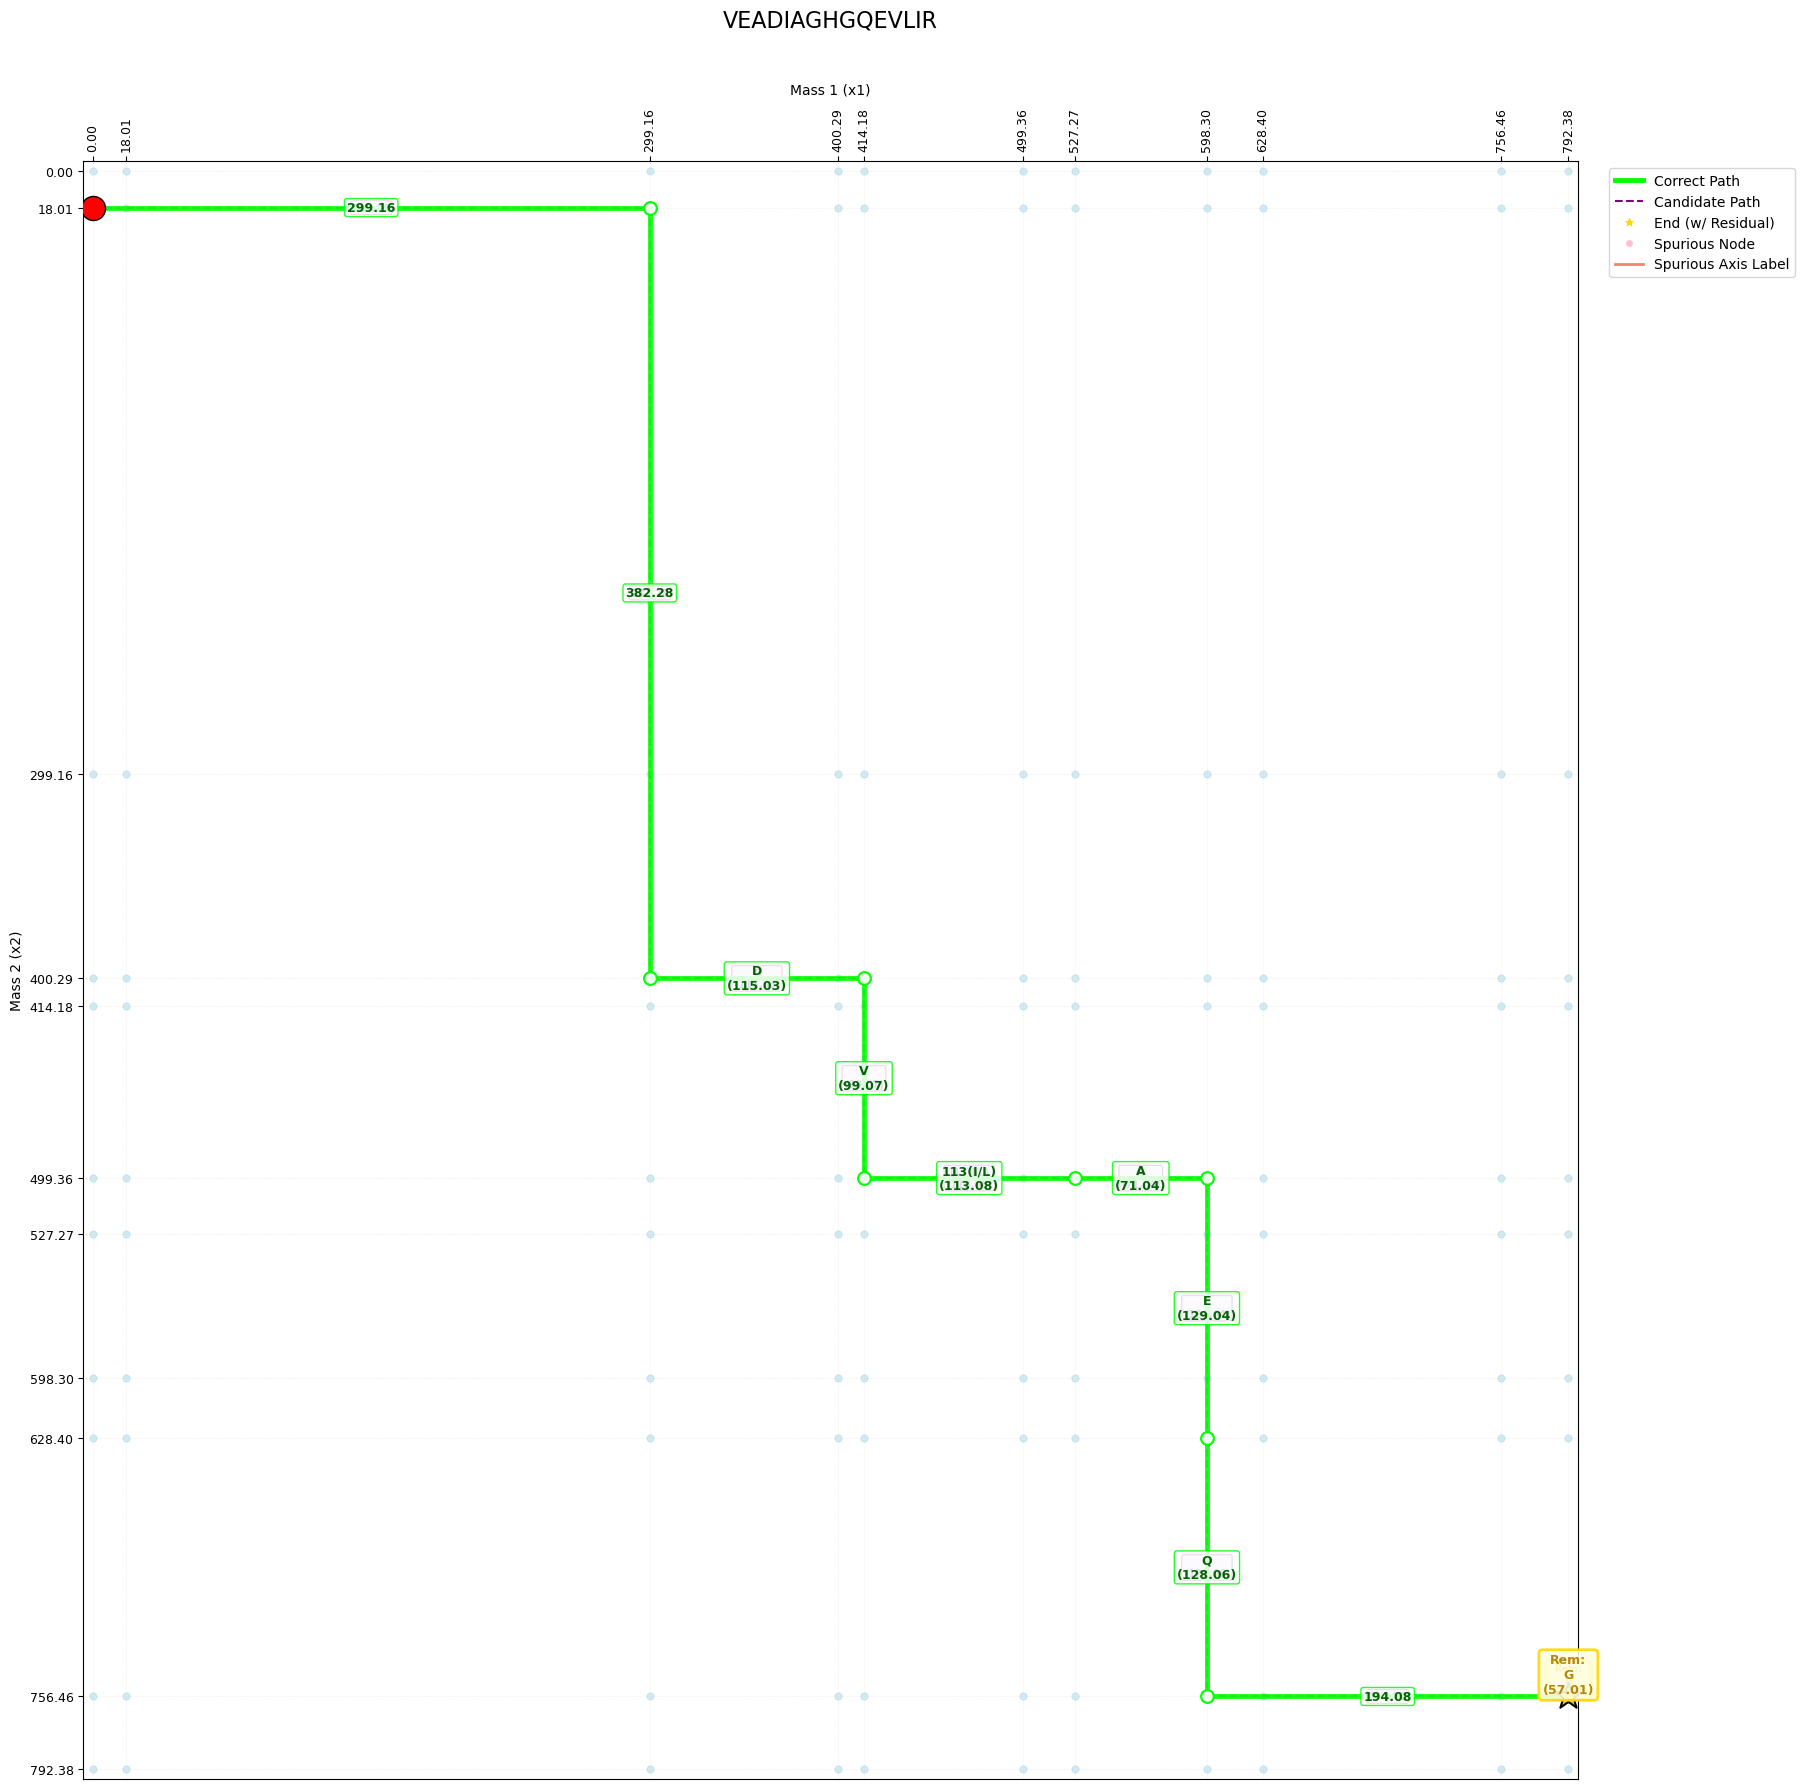

In [124]:
import os
import sys
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
import matplotlib.patches as patches
import anti_symmetric_util as ay_util
import img2pdf

current_dir = Path.cwd()

# Parent directory
parent_dir = current_dir.parent

# Directories containing your modules
vis_dir = parent_dir / "vis"
connected_graphs_dir = parent_dir / "vis_connect"
long_dir = parent_dir / "long_peptide"

# Put them at the front of sys.path
sys.path.insert(0, str(vis_dir))
sys.path.insert(0, str(connected_graphs_dir))
sys.path.insert(0, str(long_dir))

import data_parse
import util
import peptide
import pandas as pd
import numpy as np
import connected_graph
from bisect import bisect_left



def format_path_string(path, with_aa= False):
    """
    Helper to turn a list of nodes [(0,0), (0,2)...] into the arrow string format
    Rounds numbers for cleaner display.
    """
    if not path: return ""
    
    def fmt_node(n):
        return f"({round(n[0], 3)}, {round(n[1], 3)})"
    
    output = fmt_node(path[0])
    
    for i in range(len(path) - 1):
        curr = path[i]
        next_n = path[i+1]
        
        # Determine direction
        # We use a small epsilon for direction check due to float precision,
        # though standard inequality usually works fine.
        if next_n[0] > curr[0]:
            direction = "Down ↓"
        else:
            direction = "Right →"
        if with_aa:
            if direction == "Down ↓":
                mass = round(next_n[0] - curr[0], 3)
            else:
                mass = round(next_n[1] - curr[1], 3)
            aa = None
            for key, value in amino_acid_masses.items():
                if abs(value - mass) <= 0.01:  # Allow small tolerance for matching
                    aa = key
                    break
            output += f" {direction}({aa}) {fmt_node(next_n)}"
        else:
        
            output += f" {direction} {fmt_node(next_n)}"
        
    return output


amino_acid_masses_merge = {
        "A": 71.03711,   # Alanine
        "R": 156.10111,  # Arginine
        "N": 114.04293,  # Asparagine
        "D": 115.02694,  # Aspartic acid
        "C": 103.00919,  # Cysteine
        "E": 129.04259,  # Glutamic acid
        "Q": 128.05858,  # Glutamine
        "G": 57.02146,   # Glycine
        "H": 137.05891,  # Histidine
        "113(I/L)": 113.08406,  # Isoleucine
        #"L": 113.08406,  # Leucine
        "K": 128.09496,  # Lysine
        "M": 131.04049,  # Methionine
        "F": 147.06841,  # Phenylalanine
        "P": 97.05276,   # Proline
        "S": 87.03203,   # Serine
        "T": 101.04768,  # Threonine
        "W": 186.07931,  # Tryptophan
        "Y": 163.06333,  # Tyrosine
        "V": 99.06841    # Valine
    }

AA_MASSES = connected_graph.AA_MASSES
DOUBLE_AA_MASSES = connected_graph.DOUBLE_AA_MASSES
TRIPLE_AA_MASSES = connected_graph.TRIPLE_AA_MASSES
QUADRA_AA_MASSES = connected_graph.QUADRA_AA_MASSES


SOURCE_NODE = (0.0, 18.01056)
SINK_NODE = "Sink"

def construct_graph_nodes(spectrum):
    """
    Constructs the 2D grid nodes.
    Ensures the specific SOURCE_NODE (0, 18.01056) exists.
    """
    # 1. Ensure the specific coordinates for the source exist in the spectrum
    #    so the grid generation creates the node naturally.
    #    (Using a set to avoid duplicates)
    extended_spectrum = set(spectrum)
    extended_spectrum.add(SOURCE_NODE[0])
    extended_spectrum.add(SOURCE_NODE[1])
    sorted_spectrum = sorted(list(extended_spectrum))

    nodes = []
    
    # 2. Generate Grid
    for x1 in sorted_spectrum:
        for x2 in sorted_spectrum:
            # Rule: Remove diagonals (x1 == x2), unless it is the Source Node
            # (Note: (0, 18.01) is not diagonal, so it survives naturally, 
            #  but we keep the check just in case you revert to (0,0))
            if x1 != x2 or (x1 == SOURCE_NODE[0] and x2 == SOURCE_NODE[1]):
                nodes.append((x1, x2))
                
    return nodes

def build_adjacency_graph(nodes, allowed_masses, total_peptide_mass, threshold=0.01):
    """
    Constructs the graph edges, including Down, Right, and Sink connections.
    
    Args:
        nodes (list): List of (x1, x2) tuples.
        allowed_masses (list): List of valid mass gaps (AAs).
        total_peptide_mass (float): The total mass M of the peptide.
        threshold (float): Tolerance.
    """
    # Initialize graph
    graph = {node: [] for node in nodes}
    
    # Pre-processing for O(1) lookups
    valid_nodes_set = set(nodes)
    
    # Create a sorted lookup for allowed masses (for Sink check)
    sorted_allowed_masses = sorted(allowed_masses)
    
    # Create a sorted lookup for node coordinate existence (for Down/Right checks)
    # We combine all x1 and x2 values appearing in nodes to form the 'coordinate space'
    unique_coords = sorted(list(set([n[0] for n in nodes] + [n[1] for n in nodes])))

    def find_match_in_list(target, sorted_list):
        """Helper: Returns the matching value from a sorted list if within threshold."""
        idx = bisect_left(sorted_list, target)
        if idx < len(sorted_list) and abs(sorted_list[idx] - target) <= threshold:
            return sorted_list[idx]
        if idx > 0 and abs(sorted_list[idx - 1] - target) <= threshold:
            return sorted_list[idx - 1]
        return None

    for current_node in graph:
        x1, x2 = current_node
        max_current = max(x1, x2)
        
        # ---------------------------------------------------
        # 1. Check Sink Connection
        # Condition: TotalMass - x1 - x2 = Valid Mass
        # ---------------------------------------------------
        remainder = total_peptide_mass - x1 - x2
        
        # Only check if remainder is positive and physically possible
        if remainder > 0: 
            matched_mass = find_match_in_list(remainder, sorted_allowed_masses)
            if matched_mass is not None:
                # We found a bridge to the sink!
                # Edge Type: 'sink', Label: The mass that bridges the gap
                graph[current_node].append((SINK_NODE, matched_mass, 'sink'))

        # ---------------------------------------------------
        # 2. Check Standard Growth Edges (Down / Right)
        # ---------------------------------------------------
        for mass in allowed_masses:
            
            # --- DOWN Edge (x1 -> x1 + mass) ---
            target_x1 = find_match_in_list(x1 + mass, unique_coords)
            if target_x1 is not None:
                target_node = (target_x1, x2)
                if target_node in valid_nodes_set:
                    # Growth Condition
                    if max_current < max(target_x1, x2):
                        graph[current_node].append((target_node, mass, 'down'))

            # --- RIGHT Edge (x2 -> x2 + mass) ---
            target_x2 = find_match_in_list(x2 + mass, unique_coords)
            if target_x2 is not None:
                target_node = (x1, target_x2)
                if target_node in valid_nodes_set:
                    # Growth Condition
                    if max_current < max(x1, target_x2):
                        graph[current_node].append((target_node, mass, 'right'))

    return graph


def find_longest_path(graph, start_node, sink_node="Sink"):
    """
    Finds the longest path from start_node to sink_node in the DAG.
    
    Args:
        graph (dict): Adjacency dict {node: [(neighbor, mass, type), ...]}.
        start_node (tuple): The (0.0, 18.01...) source node.
        sink_node (str): The identifier for the sink.
        
    Returns:
        tuple: (max_length, path_of_masses, path_of_nodes)
               - max_length: Number of edges (amino acids).
               - path_of_masses: List of masses (e.g., [71.0, 57.0...]).
               - path_of_nodes: The sequence of graph nodes visited.
    """
    
    # Memoization table: stores result for nodes we've already solved
    # Format: { node: (length, [mass_sequence], [node_sequence]) }
    memo = {}

    def dfs(current_node):
        # 1. Base Case: Reached the Sink
        if current_node == sink_node:
            return (0, [], [sink_node])
        
        # 2. Check Memoization
        if current_node in memo:
            return memo[current_node]
        
        # 3. Recursive Step: Explore all neighbors
        best_length = -1
        best_mass_seq = []
        best_node_seq = []
        
        # If node has no outgoing edges (and isn't sink), it's a dead end.
        if current_node not in graph or not graph[current_node]:
            memo[current_node] = (-1, [], [])
            return (-1, [], [])

        for neighbor, mass, edge_type in graph[current_node]:
            # Recursively solve for the neighbor
            length, mass_seq, node_seq = dfs(neighbor)
            
            # If the neighbor leads to the sink (valid path found)
            if length != -1:
                # We add +1 for the current edge we are traversing
                current_length = 1 + length
                
                # Update if this path is longer than what we've found so far
                if current_length > best_length:
                    best_length = current_length
                    best_mass_seq = [mass] + mass_seq
                    best_node_seq = [current_node] + node_seq
        
        # 4. Store result and return
        if best_length != -1:
            memo[current_node] = (best_length, best_mass_seq, best_node_seq)
        else:
            # Mark as dead end if no neighbors lead to sink
            memo[current_node] = (-1, [], [])
            
        return memo[current_node]

    # Start the search
    return dfs(start_node)




def visualize_all_paths(spectrum, spurious_masses=None, 
                              candidate_paths=None, correct_path=None, 
                              tolerance=0.02, aa_map=None, pep_mass=None,
                              title="Peptide Spectrum Graph",
                              save_path=None):
    """
    Visualizes paths with Edge Annotations AND End-Point Residual Annotations.
    
    Args:
        pep_mass (float): The total mass of the peptide. Used to calculate 
                          the residual at the end point (PepMass - x1 - x2).
    """
    
    # --- 1. Setup & Classification ---
    S = sorted(list(set(spectrum)))
    S_arr = np.array(S)
    
    spurious_set = set(spurious_masses) if spurious_masses else set()
    def is_spurious(val): return val in spurious_set

    # Create Figure
    fig, ax = plt.subplots(figsize=(18, 18))

    # --- 2. Draw Grid Lines ---
    for mass in S:
        if is_spurious(mass):
            c, a, ls = 'salmon', 0.25, '--'
        else:
            c, a, ls = 'gray', 0.2, ':'
        ax.axvline(x=mass, color=c, linestyle=ls, linewidth=0.5, alpha=a)
        ax.axhline(y=mass, color=c, linestyle=ls, linewidth=0.5, alpha=a)

    # --- 3. Draw Nodes ---
    X, Y = np.meshgrid(S, S)
    is_noise_mask = np.array([is_spurious(m) for m in S])
    X_noise, Y_noise = np.meshgrid(is_noise_mask, is_noise_mask)
    node_is_noise = X_noise | Y_noise
    
    ax.scatter(X[node_is_noise], Y[node_is_noise], s=15, c='pink', alpha=0.4, zorder=1)
    ax.scatter(X[~node_is_noise], Y[~node_is_noise], s=25, c='lightblue', alpha=0.5, zorder=2)

    # --- 4. Helpers ---
    def get_closest_in_spectrum(val):
        idx = (np.abs(S_arr - val)).argmin()
        closest = S_arr[idx]
        return closest if abs(closest - val) <= tolerance else val

    def get_snapped_path(raw_path):
        return [(get_closest_in_spectrum(px), get_closest_in_spectrum(py)) for px, py in raw_path]

    def get_anno_text(mass_diff):
        # Allow negative residuals for the end point check
        abs_diff = abs(mass_diff)
        txt = f"{mass_diff:.2f}"
        
        if aa_map:
            min_diff = tolerance + 1e-9
            best_name = None
            for aa_mass, name in aa_map.items():
                diff = abs(abs_diff - aa_mass)
                if diff <= tolerance and diff < min_diff:
                    min_diff = diff
                    best_name = name
            if best_name: 
                txt = f"{best_name}\n({mass_diff:.2f})"
        return txt

    # --- 5. Unified Drawing Function ---
    def draw_path_logic(path_data, line_color, box_color, text_color, z_order, is_hero=False):
        if not path_data or len(path_data) < 2: return

        snapped = get_snapped_path(path_data)
        
        # Style settings
        lw = 3.5 if is_hero else 1.5
        ls = '-' if is_hero else '--'
        alpha = 0.9 if is_hero else 0.6
        marker_size = 9 if is_hero else 6
        font_size = 9 if is_hero else 7
        
        # Draw Start
        start = snapped[0]
        s_size = 300 if is_hero else 100
        ax.scatter([start[0]], [start[1]], color='red', s=s_size, edgecolors='black', zorder=z_order+5)

        # Draw Edges
        for i in range(len(snapped) - 1):
            p_start = snapped[i]
            p_end = snapped[i+1]
            
            ax.plot([p_start[0], p_end[0]], [p_start[1], p_end[1]], 
                    color=line_color, linewidth=lw, alpha=alpha, linestyle=ls, 
                    marker='o', markersize=marker_size, markerfacecolor='white', 
                    markeredgecolor=line_color, markeredgewidth=1.5,
                    zorder=z_order)

            dx, dy = p_end[0] - p_start[0], p_end[1] - p_start[1]
            mass_jump = max(abs(dx), abs(dy))
            mid_x, mid_y = (p_start[0] + p_end[0]) / 2, (p_start[1] + p_end[1]) / 2
            
            ax.text(mid_x, mid_y, get_anno_text(mass_jump), 
                    ha='center', va='center', fontsize=font_size, 
                    color=text_color, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.2', fc=box_color, ec=line_color, alpha=0.85, lw=1),
                    zorder=z_order+10)

        # Draw End Node
        end = snapped[-1]
        e_size = 400 if is_hero else 150
        ax.scatter([end[0]], [end[1]], color='gold', marker='*', s=e_size, edgecolors='black', linewidth=1.5, zorder=z_order+15)
        
        # --- NEW: End Point Annotation (Residual) ---
        if pep_mass is not None:
            # Calculate what is missing: PepMass - (x1 + x2)
            residual = pep_mass - (end[0] + end[1])
            
            # Format the text (check if the missing part looks like an AA)
            res_text = get_anno_text(residual)
            label = f"Rem:\n{res_text}"
            
            # Position: Shift visually UP (va='bottom') so it sits on top of the star
            # We use a Gold/Orange box to distinguish it from edge annotations
            ax.text(end[0], end[1], label, 
                    ha='center', va='bottom', fontsize=font_size, 
                    color='darkgoldenrod', fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', ec='gold', alpha=0.9, lw=2),
                    zorder=z_order+20)

    # --- 6. Draw Paths ---
    if candidate_paths:
        for path in candidate_paths:
            draw_path_logic(path, 
                            line_color='purple', box_color='lavender', text_color='indigo',
                            z_order=20, is_hero=False)

    if correct_path:
        draw_path_logic(correct_path, 
                        line_color='lime', box_color='white', text_color='darkgreen',
                        z_order=50, is_hero=True)

    # --- 7. Axis Formatting & Colors ---
    ax.set_xticks(S)
    ax.set_yticks(S)
    ax.set_xticklabels([f"{val:.2f}" for val in S], rotation=90, fontsize=9)
    ax.set_yticklabels([f"{val:.2f}" for val in S], fontsize=9)
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')

    x_ticks = ax.xaxis.get_major_ticks()
    for tick, val in zip(x_ticks, S):
        if is_spurious(val):
            tick.label2.set_color('salmon')
            tick.label2.set_fontweight('bold')
        else:
            tick.label2.set_color('black')

    y_ticks = ax.yaxis.get_major_ticks()
    for tick, val in zip(y_ticks, S):
        if is_spurious(val):
            tick.label1.set_color('salmon')
            tick.label1.set_fontweight('bold')
        else:
            tick.label1.set_color('black')

    pad = 5
    ax.set_xlim(min(S) - pad, max(S) + pad)
    ax.set_ylim(min(S) - pad, max(S) + pad)
    ax.invert_yaxis()
    ax.set_xlabel("Mass 1 (x1)", labelpad=10)
    ax.set_ylabel("Mass 2 (x2)")

    # Legend
    custom_lines = [
        Line2D([0], [0], color='lime', lw=3.5, label='Correct Path'),
        Line2D([0], [0], color='purple', lw=1.5, linestyle='--', label='Candidate Path'),
        Line2D([0], [0], marker='*', color='w', markerfacecolor='gold', markersize=10, label='End (w/ Residual)'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='pink', label='Spurious Node'),
        Line2D([0], [0], color='salmon', lw=2, label='Spurious Axis Label')
    ]
    ax.legend(handles=custom_lines, loc='upper right', bbox_to_anchor=(1.15, 1))
    
    ax.set_title(title, pad=40, fontsize=16)
    
    if save_path:
        directory = os.path.dirname(save_path)
        if directory and not os.path.exists(directory):
            os.makedirs(directory)
        plt.tight_layout()
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        plt.close(fig)
        print(f"Graph saved successfully to: {save_path}")
    else:
        plt.tight_layout()
        plt.show()


if __name__ =='__main__':
    
    allowed_mass_list = list(AA_MASSES.values()) + list(DOUBLE_AA_MASSES.values()) + list(TRIPLE_AA_MASSES.values()) + list(QUADRA_AA_MASSES.values())
    
    #pep_seq = 'HADGSFSDEMNTILDNLAARDFINWLIQTKITD'
    pep_seq = 'VEADIAGHGQEVLIR'
    charge = 3

    pep = peptide.Pep(f'[{pep_seq}+{charge}H]{charge}+', end_h20=True)
    #breaks = [i for i in range(1, len(pep_seq))]
    #breaks = [2, 7, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
    breaks = [3, 4, 5, 6, 8, 9, 10, 11, 12]

    spec = [pep.ion_mass(f'b{i}') for i in breaks] + [pep.ion_mass(f'y{len(pep_seq) - i}') for i in breaks]
    spec = [i-1 for i in spec]
    spec = [0] + [18.01056] + spec + [pep.pep_mass] + [938.464043*3-1, 953.522196-1]
    spec.sort()
    sorted_array = spec
    mid_point = len(sorted_array) // 2
    lower_half = sorted_array[:mid_point]
    upper_half = sorted_array[mid_point:]
    lower_half.sort()
    graph = construct_graph_nodes(lower_half)
    graph = build_adjacency_graph(nodes = graph, allowed_masses=allowed_mass_list, total_peptide_mass=pep.pep_mass - charge*1.007276, threshold=0.05)
    length, peptide_masses, node_path = find_longest_path(graph=graph, start_node=SOURCE_NODE)
    print(length)
    print(node_path)
    
    correct = node_path[:-1]
    candidates = [correct]
    
    amino_acid_masses_switch = {v: k for k, v in amino_acid_masses_merge.items()}
    
    visualize_all_paths(lower_half, spurious_masses=[938.464043*3-1, 953.522196-1], 
                         candidate_paths=candidates, 
                         correct_path=correct, 
                         aa_map=amino_acid_masses_switch,
                         title = pep_seq,
                         pep_mass=pep.seq_mass + 18.01056,
                         save_path= False)
    
    print()

In [28]:
import annot

df = pd.read_excel('/Users/kevinmbp/Desktop/2D_spec_dict/anti_symmetric/data/Covariance Scoring Tables 10000 Scans.xlsx', sheet_name='VEADIAGHGQEVLIR-mz536-3_cov')
df = df[['m/z fragment 1', 'm/z fragment 2', 'Covariance', 'Partial Cov.', 'Score', 'Ranking']]
df.columns = ['m/z A', 'm/z B', 'Covariance', 'Partial Cov.', 'Score', 'Ranking'] 
df = df[df['Score'] > 0]
data = df

data['Ranking'] = data['Ranking'].fillna(-1)
data['Ranking'] = data['Ranking'].astype(int)
data = data.sort_values('Ranking', ascending=True)
data = data[data['Ranking'] != -1]
head_num = 500
data = data.sort_values('Ranking', ascending = True)
data = data.head(head_num)
partitioned_data, partitioned_names = annot.partition_dataframe_by_charge(data, [charge, charge - 1])

In [90]:
iso = 1
loss_list = [100.068]
df_all = []
for i in loss_list:
    each_data = annot.select_best_partition(partitioned_data, ['m/z A', 'm/z B', 'Ranking'], pep.pep_mass - i, 0.1,partitioned_names, iso_range=0)
    #each_data = each_data.sort_values('Ranking', ascending=True)
    num_ffc = each_data.shape[0]
    
    each_data = annot.annotate_dataframe_loss(each_data, pep, 0.1, diffs=[i], charge=charge,iso_range=iso)
    each_data['line'] = 'parent' if i == 0 else -i
    each_data['num_ffc'] = num_ffc
    df_all.append(each_data)
df_all = pd.concat(df_all, ignore_index=True)
df_all = df_all.sort_values('Ranking', ascending = True)
df_all.head()

,m/z A,m/z B,Ranking,selected_total,component_x1,component_x2,charge_A,charge_B,adj_mass_A,adj_mass_B,...,theoretical_mass_A,iso_A,base_name_A,explanation_B,deviation_B,theoretical_mass_B,iso_B,base_name_B,line,num_ffc
10,814.482029,694.319024,23,1508.801053,814.482029,694.319024,1,1,814.482029,694.319024,...,814.47808,0,y7,(+1)-100.068,0.000166,694.31919,1,b8,-100.068,6
11,694.319024,814.482029,23,1508.801053,694.319024,814.482029,1,1,694.319024,814.482029,...,694.31919,1,b8,0,0.003949,814.47808,0,y7,-100.068,6
0,401.288604,1107.512648,29,1508.801252,401.288604,1107.512648,1,1,401.288604,1107.512648,...,401.28704,0,y3,0,0.006178,1107.50647,0,b11,-100.068,6
1,401.288604,1107.512648,29,1508.801252,401.288604,1107.512648,1,1,401.288604,1107.512648,...,401.28704,0,y3,(+1)-100.068,0.002418,1107.51023,1,b12,-100.068,6
2,401.288604,1107.512648,29,1508.801252,401.288604,1107.512648,1,1,401.288604,1107.512648,...,401.29080,1,y4,0,0.006178,1107.50647,0,b11,-100.068,6


In [91]:
breaks = [3, 4, 5, 6, 8, 9, 10, 11, 12]

b_ion = [pep.ion_mass(f'b{i}') for i in breaks]
b_ion = [i-1 for i in b_ion]
y_ion = [pep.ion_mass(f'y{len(pep_seq) - i}') for i in breaks]
y_ion = [i-1 for i in y_ion]

In [92]:
b_ion

[299.15536,
 414.18229999999994,
 527.26636,
 598.30347,
 792.38384,
 849.4053,
 977.46388,
 1106.50647,
 1205.5748800000001]

In [93]:
a1 = list(set(df_all['adj_mass_A']))
a2 = list(set(df_all['adj_mass_B']))

In [94]:
import internal
delta_val = 0.01
s, sim, virtuals = internal.find_optimal_shift_and_virtual_ions(a1, b_ion, delta=delta_val)

In [95]:
print(f"Optimal Shift (s): {s:.2f}")
print(f"SIM Score: {sim}")
print(f"Virtual Ions to add to Grandmaster Ladder: {virtuals}")

Optimal Shift (s): 98.06
SIM Score: 3
Virtual Ions to add to Grandmaster Ladder: [912.5383429999999, 1106.620215, 499.34491799999995]


In [104]:
iso = 1
loss_list = [229.111]
df_all = []
for i in loss_list:
    each_data = annot.select_best_partition(partitioned_data, ['m/z A', 'm/z B', 'Ranking'], pep.pep_mass - i, 0.1,partitioned_names, iso_range=0)
    #each_data = each_data.sort_values('Ranking', ascending=True)
    num_ffc = each_data.shape[0]
    
    each_data = annot.annotate_dataframe_loss(each_data, pep, 0.1, diffs=[i], charge=charge,iso_range=iso)
    each_data['line'] = 'parent' if i == 0 else -i
    each_data['num_ffc'] = num_ffc
    df_all.append(each_data)
df_all = pd.concat(df_all, ignore_index=True)
df_all = df_all.sort_values('Ranking', ascending = True)

a1 = list(set(df_all['adj_mass_A']))
a2 = list(set(df_all['adj_mass_B']))
s, sim, virtuals = internal.find_optimal_shift_and_virtual_ions(a1, y_ion, delta=delta_val)
print(f"Optimal Shift (s): {s:.2f}")
print(f"SIM Score: {sim}")
print(f"Virtual Ions to add to Grandmaster Ladder: {virtuals}")



Optimal Shift (s): -1.01
SIM Score: 6
Virtual Ions to add to Grandmaster Ladder: [287.192438, 1090.543166, 427.204033, 174.108041, 878.388184, 749.344953, 370.18224899999996, 1203.6274379999998, 564.263613, 621.285369, 977.457572, 950.530301]


15
[(0.0, 18.01056), (99.065, 18.01056), (99.065, 174.108041), (228.109, 174.108041), (228.109, 287.192438), (299.15536, 287.192438), (299.15536, 400.28704), (414.18229999999994, 400.28704), (414.18229999999994, 499.35544999999996), (527.26636, 499.35544999999996), (598.30347, 499.35544999999996), (598.30347, 628.39804), (598.30347, 756.45662), (598.30347, 813.4780800000001), (598.30347, 950.530301), 'Sink']


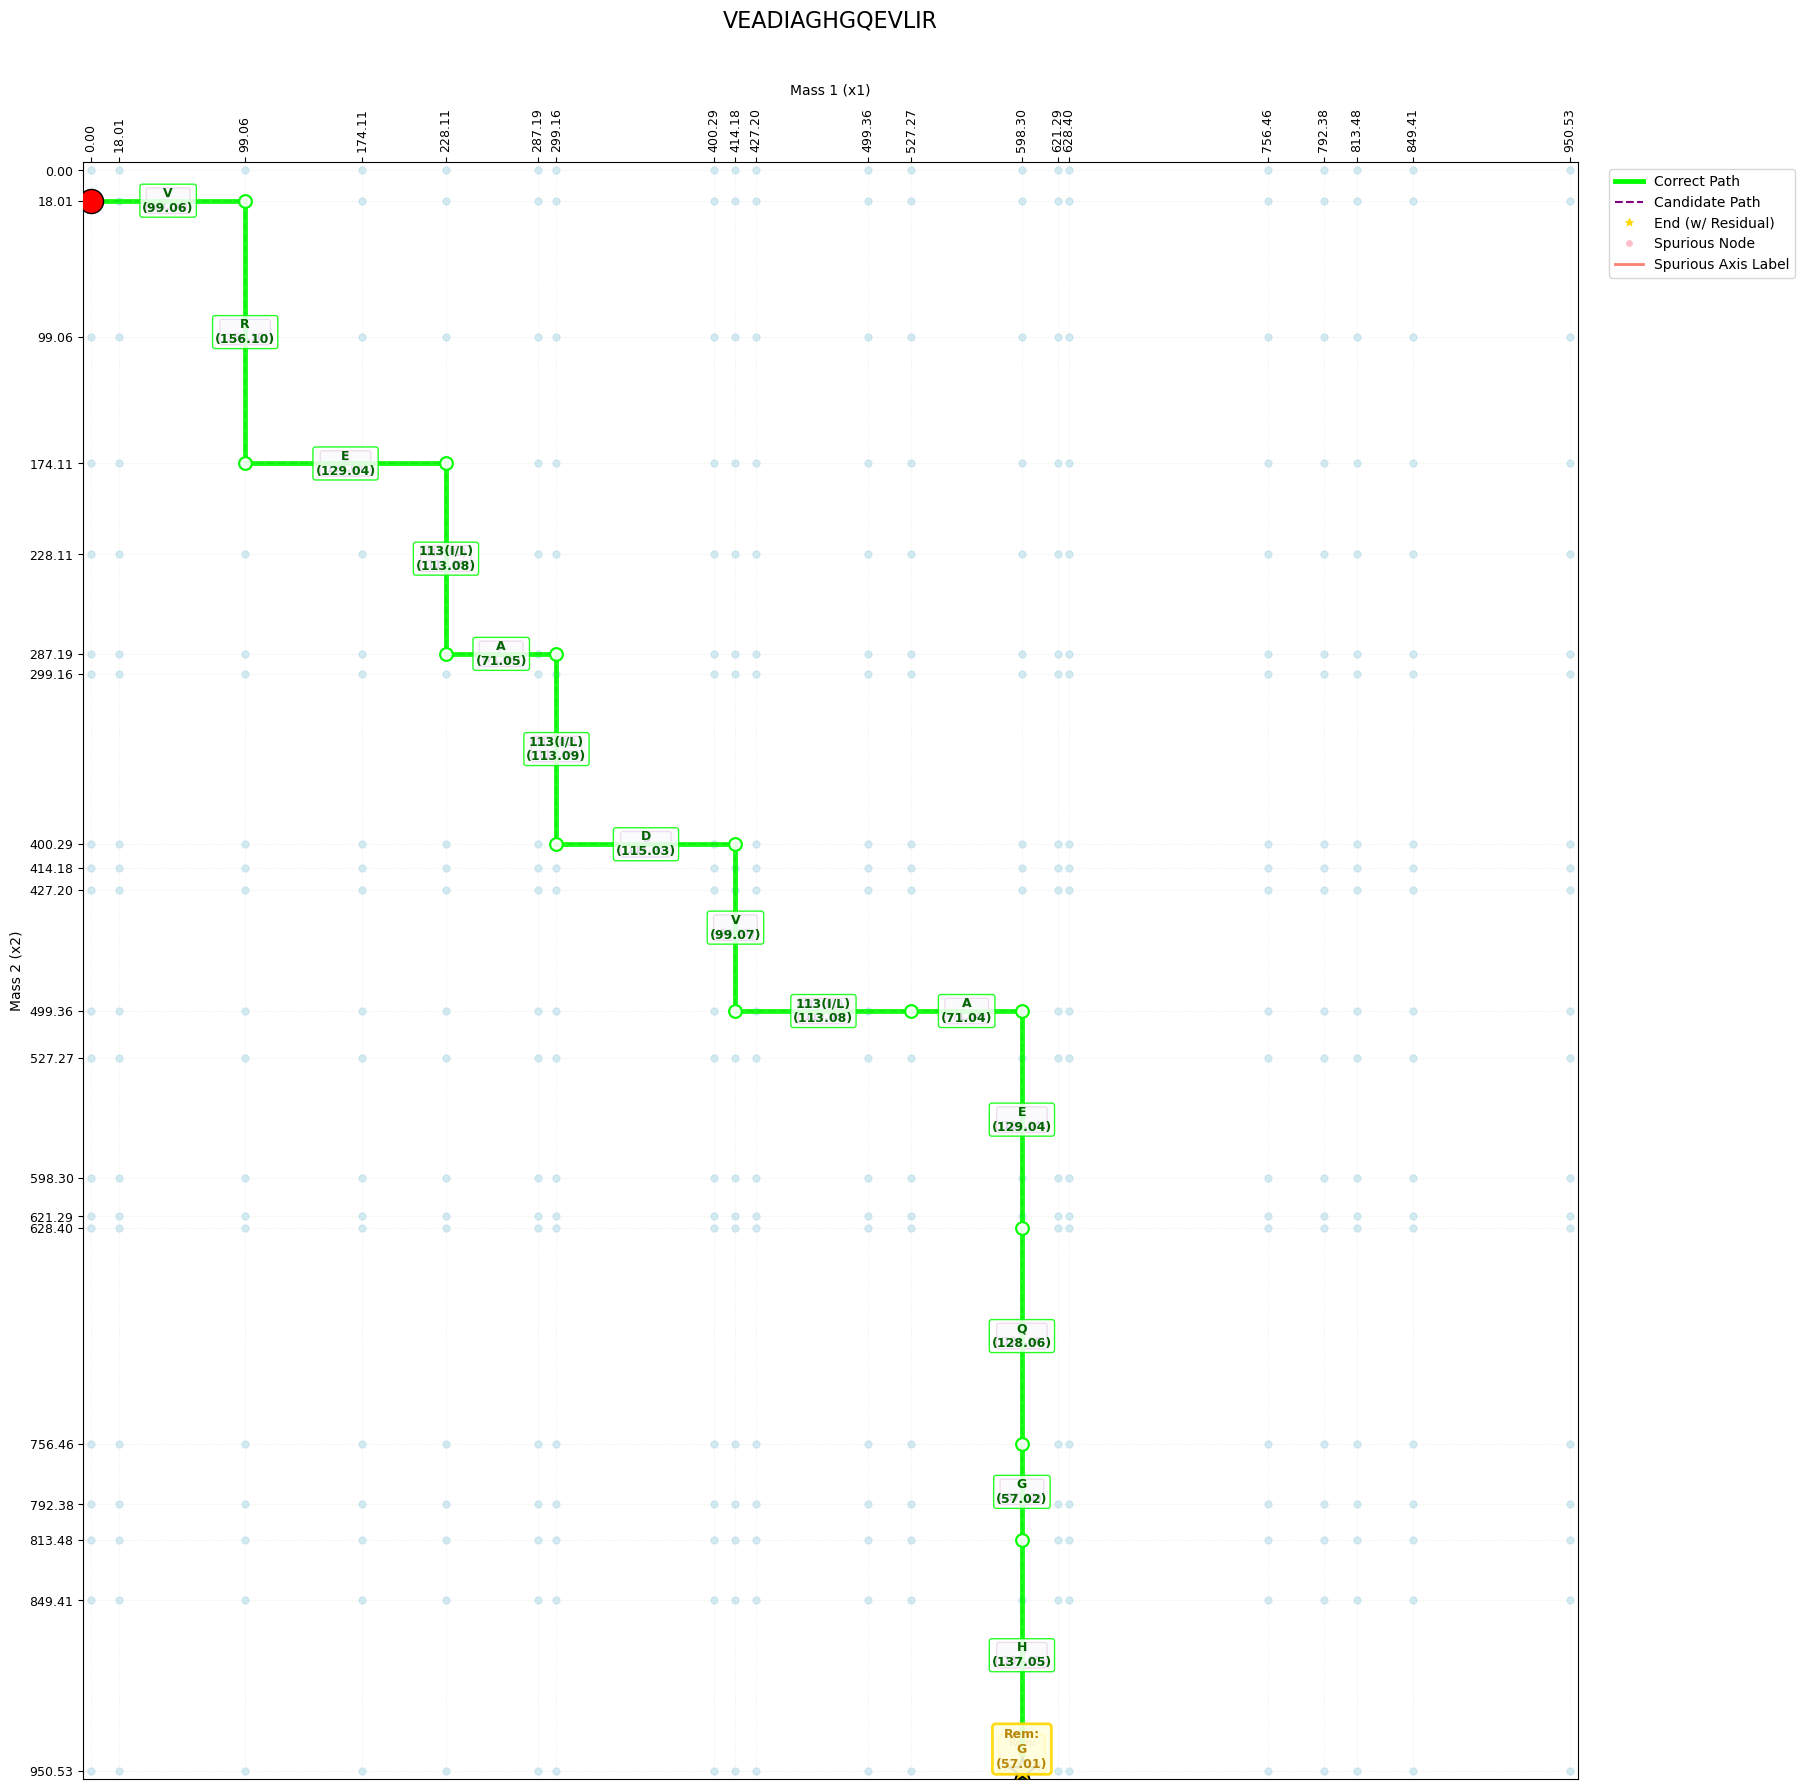

In [123]:
if __name__ =='__main__':
    
    allowed_mass_list = list(AA_MASSES.values()) + list(DOUBLE_AA_MASSES.values()) + list(TRIPLE_AA_MASSES.values()) + list(QUADRA_AA_MASSES.values())
    
    #pep_seq = 'HADGSFSDEMNTILDNLAARDFINWLIQTKITD'
    pep_seq = 'VEADIAGHGQEVLIR'
    charge = 3

    pep = peptide.Pep(f'[{pep_seq}+{charge}H]{charge}+', end_h20=True)
    #breaks = [i for i in range(1, len(pep_seq))]
    #breaks = [2, 7, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
    breaks = [3, 4, 5, 6, 8, 9, 10, 11, 12]

    spec = [pep.ion_mass(f'b{i}') for i in breaks] + [pep.ion_mass(f'y{len(pep_seq) - i}') for i in breaks]
    spec = [i-1 for i in spec]
    spec = [0] + [18.01056] + spec + [pep.pep_mass] + [938.464043*3-1, 953.522196-1] + [287.192438, 1090.543166, 427.204033, 174.108041, 621.285369, 977.457572, 950.530301] + [99.065, 228.109]
    spec.sort()
    sorted_array = spec
    mid_point = len(sorted_array) // 2 + 4
    lower_half = sorted_array[:mid_point]
    upper_half = sorted_array[mid_point:]
    lower_half.sort()
    graph = construct_graph_nodes(lower_half)
    graph = build_adjacency_graph(nodes = graph, allowed_masses=allowed_mass_list, total_peptide_mass=pep.pep_mass - charge*1.007276, threshold=0.1)
    length, peptide_masses, node_path = find_longest_path(graph=graph, start_node=SOURCE_NODE)
    print(length)
    print(node_path)
    
    correct = node_path[:-1]
    candidates = [correct]
    
    amino_acid_masses_switch = {v: k for k, v in amino_acid_masses_merge.items()}
    
    visualize_all_paths(lower_half, spurious_masses=[938.464043*3-1, 953.522196-1], 
                         candidate_paths=candidates, 
                         correct_path=correct, 
                         aa_map=amino_acid_masses_switch,
                         title = pep_seq,
                         pep_mass=pep.seq_mass + 18.01056,
                         save_path= False)
    
    print()